In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fftshift

def calc_dft(x, y):

    Fy = fft(y)
    freqs = fftfreq(len(x), x[1]-x[0])
    Fy = fftshift(Fy)
    freqs = fftshift(freqs)

    return freqs, Fy

## 1. DFT 1D

#### Mistura de cosenos com ruído
Vamos definir um sinal dado pela mistura de duas funções coseno mais um ruído

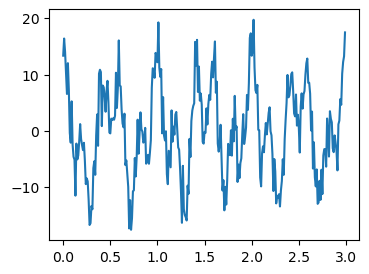

In [43]:
freq_s1 = 2.
freq_s2 = 5.
x = np.arange(0, 3, 0.01)
y = 8*np.cos(2*np.pi*freq_s1*x) + 7*np.cos(2*np.pi*freq_s2*x)
y += 3*np.random.normal(0., 1., x.size)

plt.plot(x, y)

(-10.0, 10.0)

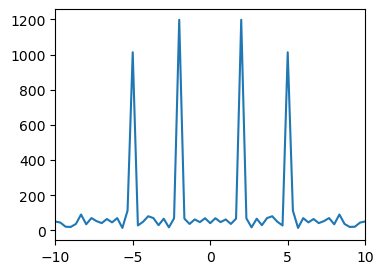

In [44]:
freqs, Fy = calc_dft(x, y)

plt.plot(freqs, np.abs(Fy))
plt.xlim((-10,10))

In [45]:
freqs[np.abs(Fy) > 200]

array([-5., -2.,  2.,  5.])

#### Função caixa

Text(0.5, 1.0, 'Transformada de Fourier')

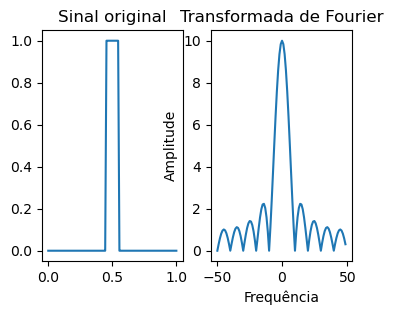

In [46]:
x = np.linspace(0, 1, 100)
y = np.zeros(len(x))
y[45:55] = 1

freqs, Fy = calc_dft(x, y)

plt.subplot(1, 2, 1)
plt.plot(x, y)
plt.title('Sinal original')
plt.subplot(1, 2, 2)
plt.plot(freqs, np.abs(Fy))
plt.xlabel('Frequência')
plt.ylabel('Amplitude')
plt.title('Transformada de Fourier')

## 2. DFT 2D de um sinal artificial

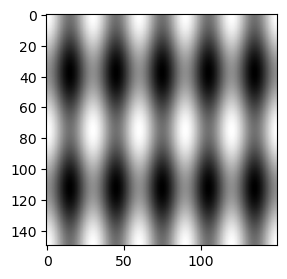

In [49]:
from scipy.fft import fft2

# Vamos definir uma imagem dada pela mistura de duas funções coseno, 
# cada uma em uma direção (horizontal e vertical), mais um ruído
n = 150
quant_ruido = 0.
freq_r = 2./n    # 2 ciclos de coseno ao longo das linhas
freq_c = 5./n    # 5 ciclos de coseno ao longo das colunas
img = np.zeros((n, n))
for row in range(n):
    for col in range(n):
        img[row, col] = 4*np.cos(2*np.pi*freq_r*row) + 5*np.cos(2*np.pi*freq_c*col)
        img[row, col] += quant_ruido*np.random.normal(0., 1.)
plt.imshow(img, 'gray')

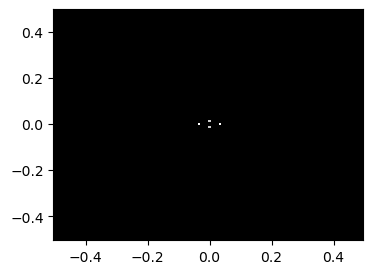

In [ ]:
Fimg = fft2(img)
freqs = fftfreq(n, 1.)
Fimg = fftshift(Fimg)         
freqs = fftshift(freqs)
plt.pcolormesh(freqs, freqs, np.abs(Fimg), cmap='gray')

(-0.1, 0.1)

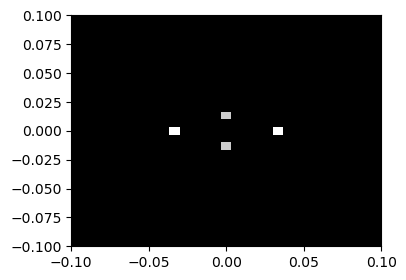

In [ ]:
# Zoom nas frequências mais baixas (no centro do espectro)
plt.pcolormesh(freqs, freqs, np.abs(Fimg), cmap='gray')
plt.xlim((-0.1, 0.1))
plt.ylim((-0.1, 0.1))

(-0.1, 0.1)

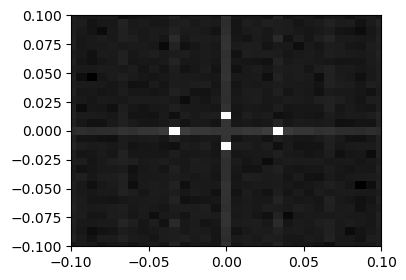

In [54]:
plt.pcolormesh(freqs, freqs, np.log(np.abs(Fimg)), cmap='gray')
plt.xlim((-0.1, 0.1))
plt.ylim((-0.1, 0.1))

## 3. DFT 2D de imagens com repetição

In [55]:
from pathlib import Path

def calc_fourier_and_plot(img):
    """Calcula transformada de Fourier de uma imagem e plota o resultado"""
    num_rows, num_cols = img.shape

    Fimg = fft2(img)
    freq_r = fftfreq(num_rows)
    freq_c = fftfreq(num_cols)

    Fimg = fftshift(Fimg)
    freq_r = fftshift(freq_r)
    freq_c = fftshift(freq_c)
    plt.figure(figsize=[8,8])
    plt.pcolormesh(freq_c, freq_r, np.log(np.abs(Fimg)), cmap='gray')

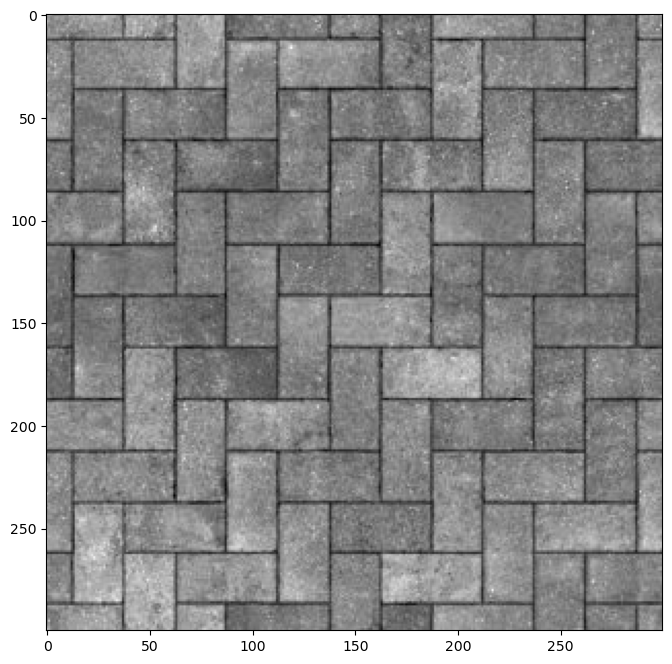

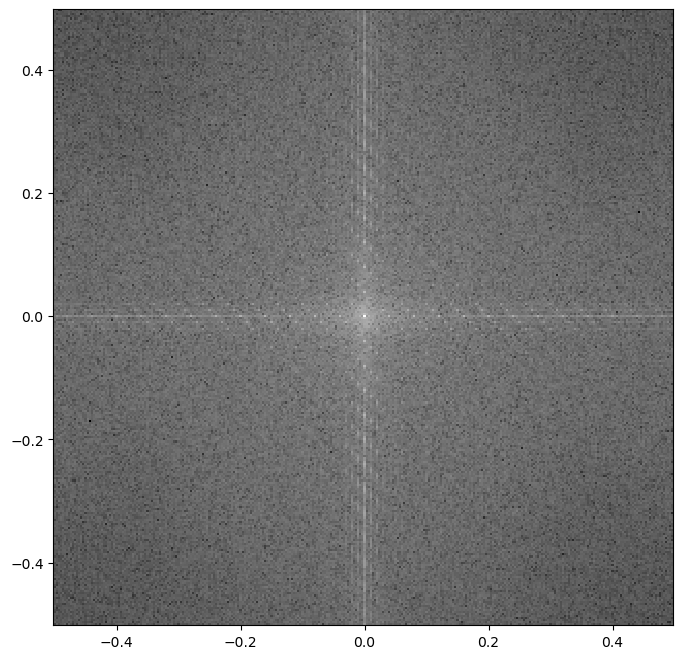

In [56]:
root_dir = Path("../../dados")

img = plt.imread(root_dir / "tiles/tiles1.tiff")
plt.figure(figsize=[8,8])
plt.imshow(img, 'gray')

calc_fourier_and_plot(img)

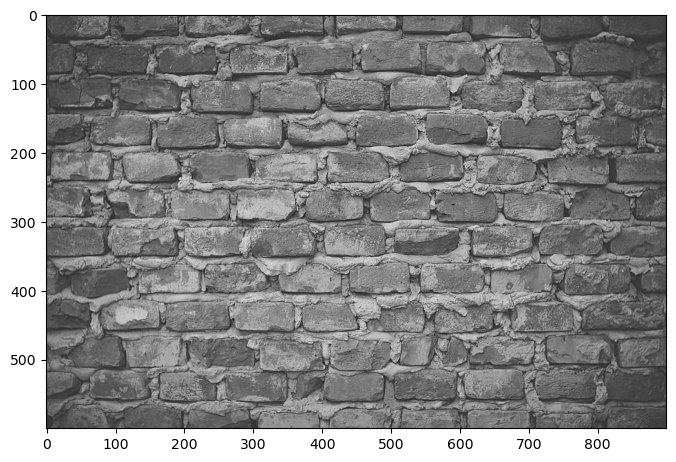

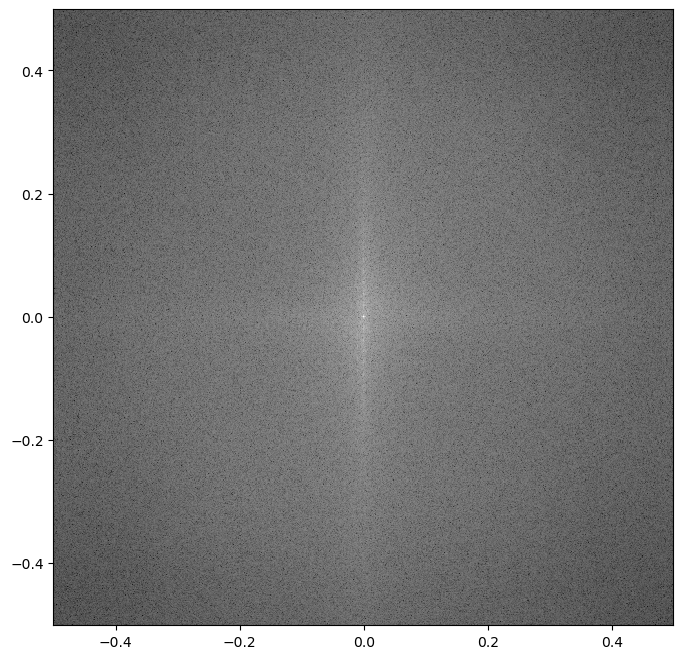

In [57]:
img = plt.imread(root_dir / "tiles/tiles2.tiff")
plt.figure(figsize=[8,8])
plt.imshow(img, 'gray')

calc_fourier_and_plot(img)

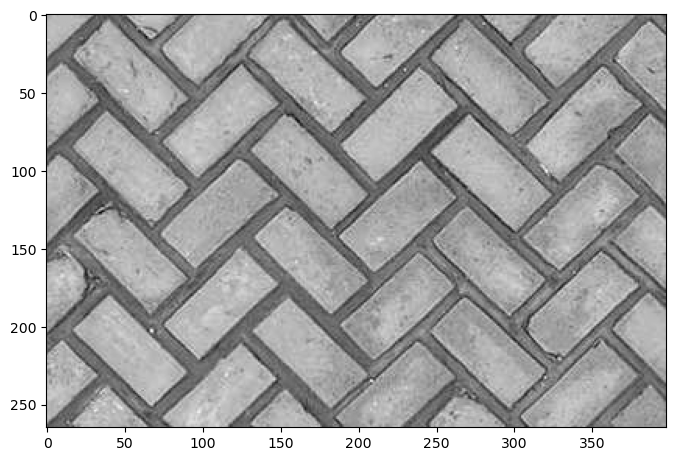

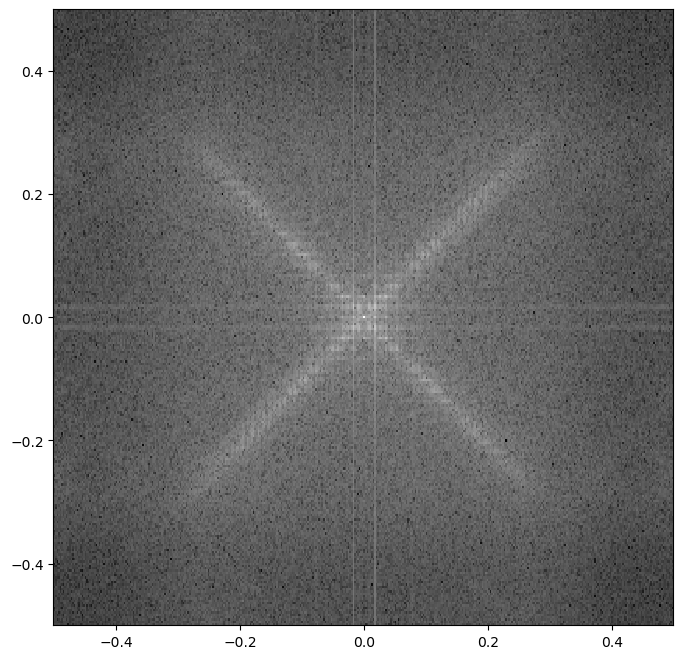

In [58]:
img = plt.imread(root_dir / "tiles/tiles3.tiff")
plt.figure(figsize=[8,8])
plt.imshow(img, 'gray')

calc_fourier_and_plot(img)

## 4. DFT 2D de uma imagem qualquer

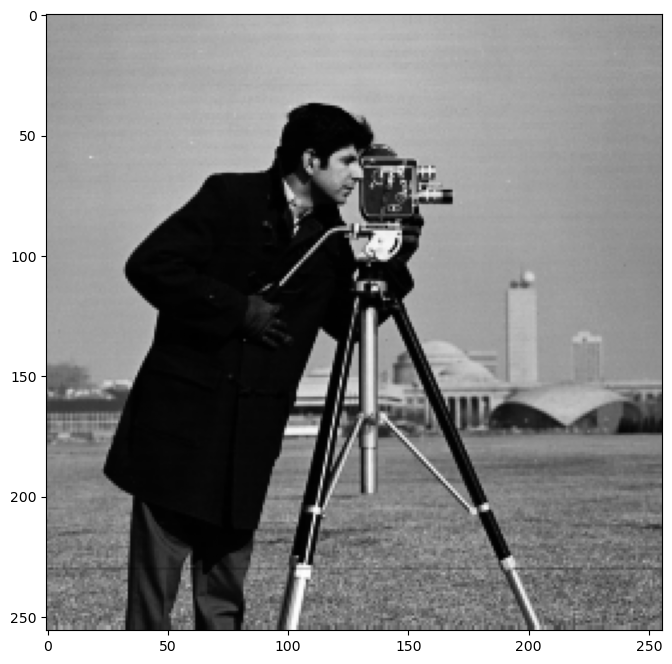

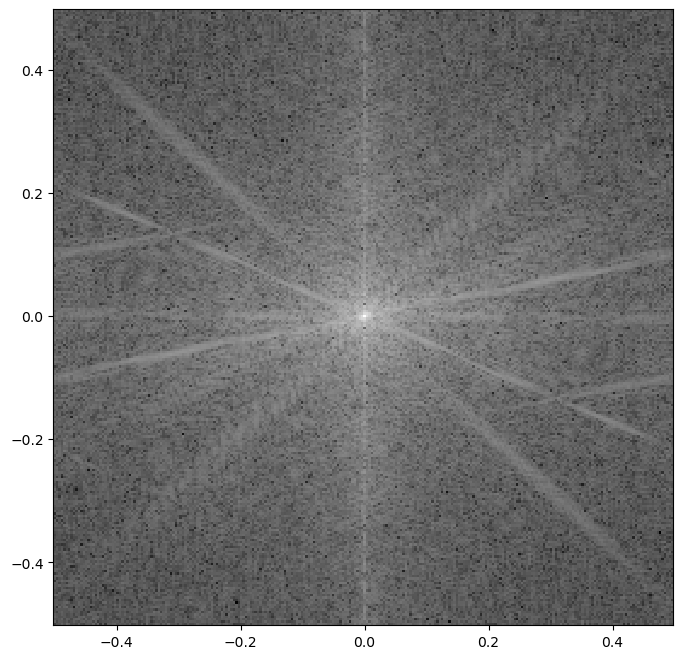

In [59]:
img = plt.imread(root_dir / "cameraman.tiff")
plt.figure(figsize=[8,8])
plt.imshow(img, 'gray')

calc_fourier_and_plot(img)